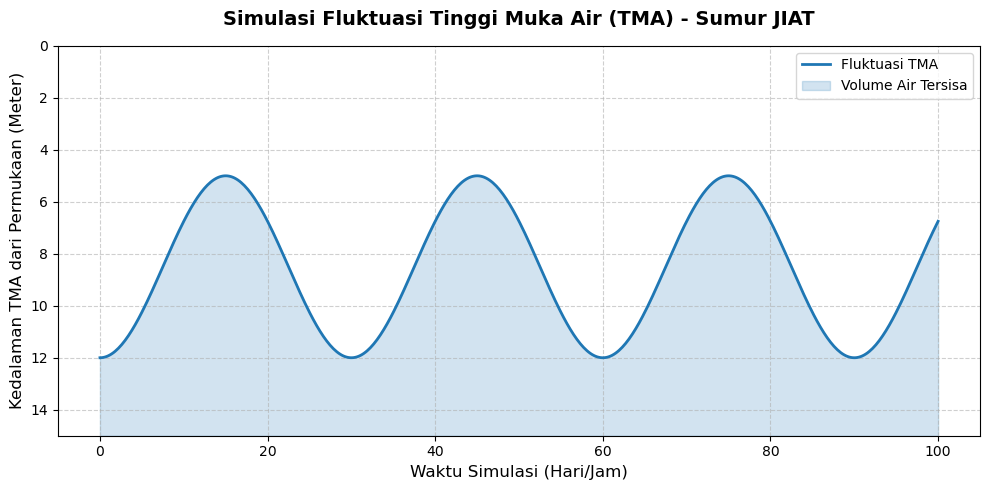

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Menyiapkan data waktu simulasi (contoh: 0 sampai 100 satuan waktu)
time = np.linspace(0, 100, 500)

# 2. Membuat pola cosine untuk simulasi kedalaman muka air (TMA)
# Asumsi fluktuasi TMA berada ideal di kedalaman 5m hingga 12m
amplitude = 3.5          # Seberapa besar fluktuasi kedalamannya
offset_depth = 8.5      # Titik tengah kedalaman (8.5 meter)
period = 30             # Periode siklus

# Rumus TMA berombak dengan cosine
tma_simulated = offset_depth + amplitude * np.cos(2 * np.pi * time / period)

# 3. Membuat Plot
plt.figure(figsize=(10, 5))
plt.plot(time, tma_simulated, color='#1f77b4', linewidth=2, label='Fluktuasi TMA')

# Membalikkan sumbu Y: 0 (permukaan) di atas, 15 (kedalaman) di Bawah
plt.ylim(15, 0)

# Konfigurasi Tampilan
plt.title('Simulasi Fluktuasi Tinggi Muka Air (TMA) - Sumur JIAT', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Waktu Simulasi (Hari/Jam)', fontsize=12)
plt.ylabel('Kedalaman TMA dari Permukaan (Meter)', fontsize=12)

# Mengisi warna area air/bawah tanah agar lebih visual
plt.fill_between(time, tma_simulated, 15, color='#1f77b4', alpha=0.2, label='Volume Air Tersisa')

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')

# Menyesuaikan margin dan menampilkan plot
plt.tight_layout()
plt.show()

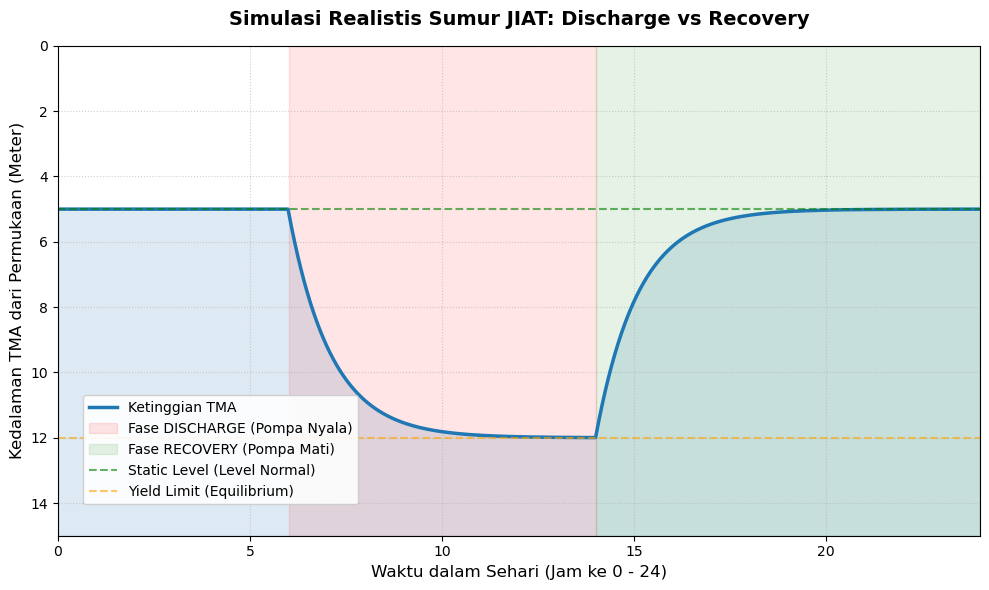

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_aquifer_response(t, pump_on, static_tma, max_drawdown, recovery_rate):
    """
    Fungsi iteratif untuk menghitung respons muka air tanah.
    Model menggunakan pendekatan eksponensial naik/turun layaknya Theis Recovery.
    """
    tma = np.zeros_like(t)
    current_tma = static_tma
    
    for i in range(len(t)):
        if pump_on[i] == 1:
            # FASE DISCHARGE: 
            # Pompa dihidupkan, air turun menjauhi permukaan (angka bertambah).
            # TMA akan turun melengkung pelan-pelan menuju batas Yield seimbangnya.
            target = static_tma + max_drawdown
            current_tma += (target - current_tma) * recovery_rate 
        else:
            # FASE RECOVERY:
            # Pompa dimatikan, air kembali memulihkan diri menuju level Statis.
            current_tma += (static_tma - current_tma) * recovery_rate
            
        tma[i] = current_tma
        
    return tma

# 1. Setup Waktu (Simulasi 24 Jam Penuh, resolusi per menit)
time = np.linspace(0, 24, 1440) # 1440 menit dalam 24 jam

# 2. Setup Jadwal Pemompaan (0 = Mati, 1 = Nyala)
pump_status = np.zeros_like(time)
# Misal, sawah diairi dari Jam 06:00 Pagi sampai 14:00 Siang
pump_status[(time >= 6) & (time < 14)] = 1 

# 3. Parameter Akuifer (Realistik)
STATIC_TMA   = 5.0     # Kedalaman Normal/Awal (5 meter)
MAX_DRAWDOWN = 7.0     # Kedalaman mentok saat discharge seimbang dengan Yield (turun 7 meter ekstra)
RECOVERY_RATE = 0.015  # Cepat lambatnya rembesan/pulih (Makin besar = makin cepat airnya ngisi)

# Jalankan kalkulasi TMA
tma = simulate_aquifer_response(time, pump_status, STATIC_TMA, MAX_DRAWDOWN, RECOVERY_RATE)


# 4. Membuat Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot kurva TMA
ax.plot(time, tma, color='#1f77b4', linewidth=2.5, label='Ketinggian TMA')

# Fill area kolom air
ax.fill_between(time, tma, 15, color='#1f77b4', alpha=0.15)

# Balik Sumbu Y (0 di atas, 15 di bawah)
ax.set_ylim(15, 0)
ax.set_xlim(0, 24)

# Blok Warna Fase untuk memudahkan pembacaan
ax.axvspan(6, 14, color='red', alpha=0.1, label='Fase DISCHARGE (Pompa Nyala)')
ax.axvspan(14, 24, color='green', alpha=0.1, label='Fase RECOVERY (Pompa Mati)')

# Garis batas penting
ax.axhline(STATIC_TMA, color='green', linestyle='--', alpha=0.6, label='Static Level (Level Normal)')
# Jika Discharge > Yield, garis orange ini akan tembus terus ke bawah (mengering)
# Namun jika seimbang/Yield cukup, grafik akan mendarat melengkung pelan di garis ini (Equilibrium)
ax.axhline(STATIC_TMA + MAX_DRAWDOWN, color='orange', linestyle='--', alpha=0.6, label='Yield Limit (Equilibrium)')


# Label & Deskripsi
ax.set_title('Simulasi Realistis Sumur JIAT: Discharge vs Recovery', pad=15, fontweight='bold', fontsize=14)
ax.set_xlabel('Waktu dalam Sehari (Jam ke 0 - 24)', fontsize=12)
ax.set_ylabel('Kedalaman TMA dari Permukaan (Meter)', fontsize=12)

# Grid dan Legend
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower left', bbox_to_anchor=(0.02, 0.05), framealpha=0.9)

plt.tight_layout()
plt.show()


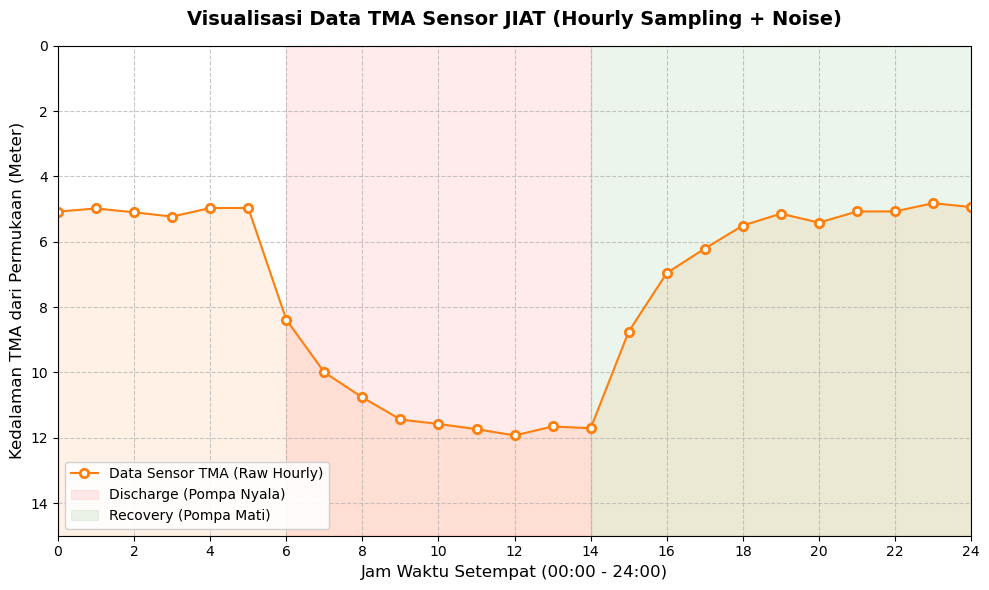

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_aquifer_hourly(t, pump_on, static_tma, max_drawdown, recovery_rate, noise_level):
    """
    Simulasi TMA dengan resolusi per jam dan tambahan Noise (Error sensor lapangan).
    """
    tma_sensor = np.zeros_like(t, dtype=float)
    current_tma = static_tma  # State Fisika Aktual (tanpa noise)
    
    # Supaya hasil random-nya tetap sama tiap kali di-run (bisa dihapus kalau ingin berbeda)
    np.random.seed(42) 
    
    for i in range(len(t)):
        if pump_on[i] == 1:
            # Fase Pemompaan
            target = static_tma + max_drawdown
            current_tma += (target - current_tma) * recovery_rate 
        else:
            # Fase Pemulihan
            current_tma += (static_tma - current_tma) * recovery_rate
            
        # Data Sensor = Fisika Aktual + Noise (Error)
        # Random normal dengan rata-rata 0 (noise_level bertindak sebagai standard deviasi)
        sensor_reading = current_tma + np.random.normal(0, noise_level)
        
        tma_sensor[i] = sensor_reading
        
    return tma_sensor

# 1. Setup Waktu (0 sampai 24 Jam dengan interval persis 1 Jam)
time_hourly = np.arange(0, 25) # Menghasilkan array: [0, 1, 2, ..., 24]

# 2. Setup Jadwal Pemompaan
pump_status = np.zeros_like(time_hourly)
pump_status[(time_hourly >= 6) & (time_hourly <= 14)] = 1 

# 3. Parameter Akuifer yang dimodifikasi untuk Skala Jam
STATIC_TMA   = 5.0     
MAX_DRAWDOWN = 7.0     
# Rate diperbesar karena jeda perhitungannya sekarang per 1 jam (bukan per menit)
RECOVERY_RATE_HOURLY = 0.45 
# Noise/fluktuasi sensor sebesar ~15 cm (0.15 meter)
NOISE_LEVEL = 0.15 

# Jalankan simulasi
tma_data = simulate_aquifer_hourly(time_hourly, pump_status, STATIC_TMA, MAX_DRAWDOWN, RECOVERY_RATE_HOURLY, NOISE_LEVEL)


# 4. Membuat Plot (Dengan gaya Scatter Plot Line)
fig, ax = plt.subplots(figsize=(10, 6))

# Menggunakan marker 'o' untuk menegaskan titik pengambilan data (sampling) tiap jam
ax.plot(time_hourly, tma_data, color='#ff7f0e', linewidth=1.5, linestyle='-', 
        marker='o', markersize=6, markerfacecolor='white', markeredgewidth=2,
        label='Data Sensor TMA (Raw Hourly)')

# Fill area kolom air
ax.fill_between(time_hourly, tma_data, 15, color='#ff7f0e', alpha=0.1)

# Balik Sumbu Y (0 di atas, 15 di bawah) & Setup sumbu X
ax.set_ylim(15, 0)
ax.set_xlim(0, 24)
ax.set_xticks(np.arange(0, 25, 2)) # Beri tanda X-axis tiap 2 jam

# Blok Warna Fase
ax.axvspan(6, 14, color='red', alpha=0.08, label='Discharge (Pompa Nyala)')
ax.axvspan(14, 24, color='green', alpha=0.08, label='Recovery (Pompa Mati)')

# Lebel & Grid
ax.set_title('Visualisasi Data TMA Sensor JIAT (Hourly Sampling + Noise)', pad=15, fontweight='bold', fontsize=14)
ax.set_xlabel('Jam Waktu Setempat (00:00 - 24:00)', fontsize=12)
ax.set_ylabel('Kedalaman TMA dari Permukaan (Meter)', fontsize=12)

ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(loc='lower left', framealpha=0.9)

plt.tight_layout()
plt.show()


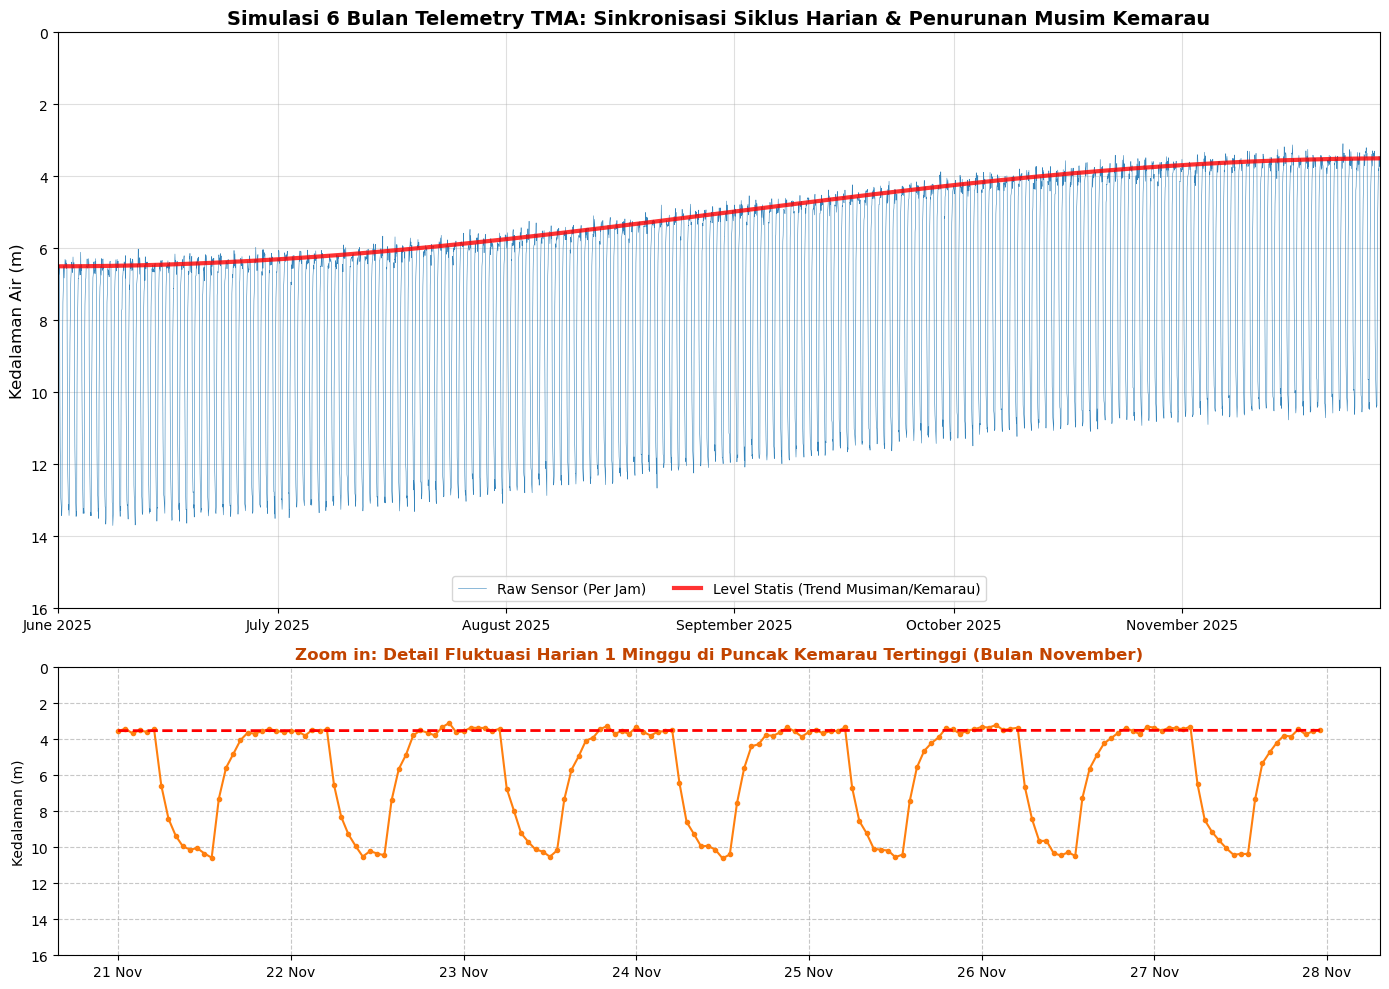

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def simulate_aquifer_6months(time_series, pump_on, base_tma, max_drawdown, recovery_rate, noise_level):
    """
    Simulasi simulasi TMA (per jam) jangka panjang dengan Efek Musiman.
    """
    tma_sensor = np.zeros(len(time_series), dtype=float)
    
    # 1. Menambahkan Tren Musiman Alamiah (misal siklus 365 hari kalender)
    # Ini akan membuat level dasar (statis) air tanah perlahan surut (turun) dan naik lagi.
    days = np.arange(len(time_series)) / 24.0
    # Gelombang cosine simulasi fluktuasi musim sebesar +/- 1.5 meter
    seasonal_trend = 1.5 * np.cos(2 * np.pi * days / 365.0) 
    
    current_tma = base_tma + seasonal_trend[0]
    np.random.seed(42)
    
    for i in range(len(time_series)):
        # Muka air alamiah mengikuti musim pada jam tersebut
        dynamic_static_tma = base_tma + seasonal_trend[i]
        
        if pump_on[i] == 1:
            target = dynamic_static_tma + max_drawdown
            current_tma += (target - current_tma) * recovery_rate 
        else:
            current_tma += (dynamic_static_tma - current_tma) * recovery_rate
            
        # Simpan nilai sensor ditambahkan noise
        tma_sensor[i] = current_tma + np.random.normal(0, noise_level)
        
    return tma_sensor, base_tma + seasonal_trend

# =======================================================
# 1. SETUP WAKTU: 6 Bulan (Total = 4320 titik data)
# Kita mulai dari bulan Juni misalnya (Awal Kemarau)
time_series = pd.date_range(start='2025-06-01', periods=180*24, freq='h')

# 2. SETUP POMPA: Jadwal Rutin
# Pompa Nyala tiap Jam 06:00 Pagi, Mati Jam 14:00 Siang, setiap harinya selama 6 bulan
pump_status = np.zeros(len(time_series))
pump_status[(time_series.hour >= 6) & (time_series.hour < 14)] = 1 

# 3. SETUP PARAMETER AKUIFER
BASE_STATIC_TMA = 5.0      # Rata-rata Normal
MAX_DRAWDOWN = 7.0         # Tumpuan Yield Limit
RECOVERY_RATE_HOURLY = 0.45 
NOISE_LEVEL = 0.15         # Noise Sensor Telemetry

# Menjalankan Algoritma Simulasi
tma_data, seasonal_baseline = simulate_aquifer_6months(
    time_series, pump_status, BASE_STATIC_TMA, MAX_DRAWDOWN, RECOVERY_RATE_HOURLY, NOISE_LEVEL
)

# Memasukkan ke DataFrame Pandas (Bisa di-eksport jadi CSV nanti)
df_tma = pd.DataFrame({
    'timestamp': time_series,
    'pump_status': pump_status,
    'tma_reading_meters': tma_data,
    'static_baseline': seasonal_baseline
})
# =======================================================

# 4. MEMBUAT VISUALISASI DATA 6 BULAN (OVERVIEW)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# --- Grafik Atas: Overview 6 Bulan Penuh ---
# Sengaja ketebalan garis ditipiskan (0.4) karena 4000+ data perjam tertumpuk rapat.
ax1.plot(df_tma['timestamp'], df_tma['tma_reading_meters'], color='#1f77b4', linewidth=0.4, alpha=0.9, label='Raw Sensor (Per Jam)')
# Trend Musim ditumpuk agar terlihat
ax1.plot(df_tma['timestamp'], df_tma['static_baseline'], color='red', linewidth=3, linestyle='-', alpha=0.8, label='Level Statis (Trend Musiman/Kemarau)')

ax1.set_ylim(16, 0) # Balik sumbu
ax1.set_xlim(df_tma['timestamp'].min(), df_tma['timestamp'].max())
ax1.set_title('Simulasi 6 Bulan Telemetry TMA: Sinkronisasi Siklus Harian & Penurunan Musim Kemarau', fontsize=14, fontweight='bold')
ax1.set_ylabel('Kedalaman Air (m)', fontsize=12)
ax1.grid(True, linestyle='-', alpha=0.4)
ax1.legend(loc='lower center', ncol=2)

# Rapikan X Axis per bulan
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%B %Y'))

# --- Grafik Bawah: Zoom in 1 MINGGU TERAKHIR (Sebagai Bukti Sampling Per-jam) ---
# Kita ambil 7 hari terakhir bulan November
df_zoom = df_tma.tail(24 * 7) 

ax2.plot(df_zoom['timestamp'], df_zoom['tma_reading_meters'], color='#ff7f0e', linewidth=1.5, marker='.', markersize=6, label='Detail Per-Jam Saat Kemarau Ekstrem')
ax2.plot(df_zoom['timestamp'], df_zoom['static_baseline'], color='red', linewidth=2, linestyle='--', label='Level Statis')

ax2.set_ylim(16, 0)
ax2.set_title('Zoom in: Detail Fluktuasi Harian 1 Minggu di Puncak Kemarau Tertinggi (Bulan November)', fontsize=12, fontweight='bold', color='#c24400')
ax2.set_ylabel('Kedalaman (m)')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

plt.tight_layout()
plt.show()

# Tampilkan preview datanya (bisa di df_tma.to_csv('simulasi_6bln.csv') jika ingin disematkan di folder data)
# df_tma.head()


Untuk menentukan Waktu Pemulihan (*Recovery Time*) dari data TMA (terutama yang penuh *noise*), ada beberapa metode yang bisa Anda pilih, mulai dari yang paling simpel hingga yang saintifik secara hidrogeologi dan *data science*.

Berikut adalah 4 rekomendasi metode terbaik untuk diuji pada Python/Jupyter Notebook:

### 1. Metode Thresholding (Recovery 95%) - *Paling Mudah & Praktis*
Secara fisika, kurva *recovery* itu eksponensial (mendekati nilai awal namun butuh waktu sangat lama untuk benar-benar 100% sempurna). Oleh karena itu, di lapangan, akuifer dianggap "sudah pulih" jika TMA telah kembali sebesar **90% atau 95%** dari kedalaman mulanya.
- **Cara Kerja:** Jika *Static Level* (awal) adalah 5m, dan *Max Drawdown* (saat pompa mati) adalah 12m. Total defisit = 7m. Akuifer dianggap pulih saat air telah kembali sebesar $95\% \times 7 = 6.65m$, alias ketika TMA menyentuh kedalaman 5.35 meter.
- **Implementasi:** Anda cukup membuat *script* yang mencari indeks waktu (*timestamp*) di mana nilai rentetan data sesudah pompa mati menyentuh angka 5.35m untuk pertama kalinya.

### 2. Metode Turunan Eksponensial (dy/dt atau Laju Perubahan TMA)
Metode ini tidak peduli pada angka meter kedalamannya, melainkan mengukur "kecepatannya".
- **Cara Kerja:** Anda menghitung selisih kedalaman air dari jam ke jam (∆TMA / ∆T). Pada awal *recovery*, air mengisi dengan cepat (perubahannya besar). Lama-kelamaan air melambat. Waktu *recovery* tercapai ketika laju perubahan (`dy/dt`) mendekati angka nol atau di bawah batas toleransi (misal perubahannya kurang dari 3 cm per jam).
- **Implementasi (Python):** Gunakan `np.gradient(tma)` atau `diff()` pada pandas. Jika `abs(gradient) < 0.03`, dan pompa sedang mati, maka titik tersebut adalah akhir masa *recovery*.

### 3. Machine Learning: *Exponential Curve Fitting* (Standar IoT/Data Science)
Ini adalah **metode terbaik** jika data Anda bergerak kasar karena *noise* (seperti visualisasi terakhir kita). Data kotor akan membuat metode 1 dan 2 meleset.
- **Cara Kerja:** Kita menggunakan fungsi _machine learning_ regresi tak linier untuk menebak kurva mulus tersembunyi di balik data *noise*.
- **Implementasi (Python):**
  Anda bisa menggunakan `scipy.optimize.curve_fit`. Potong datanya khusus di bagian "pompa mati hingga selesai", lalu paksa Python untuk mencari nilai parameter $A$ dan $k$ pada persamaan matematis:
  $$TMA(t) = Static_{tma} + A \cdot e^{-kt}$$
  Setelah konstanta pemulihan alamiah ($k$) ditemukan, Anda bisa menghitung waktu prediksi *recovery* mutlak tanpa terganggu *noise* sensor.

### 4. Metode "Theis Recovery" (Standar Pakar Geologi HMTG/IAGI)
Bila data Anda nantinya dipakai sebagai kajian kelaikan operasi irigasi, _Theis Recovery Method_ adalah metode ilmiah yang diakui standar nasional RI (SNI/ESDM).
- **Cara Kerja:** Bukan menggunakan ukuran jam atau menit literal, melainkan menggunakan rasio logaritmis waktu. Anda memetakan sisa defisit air (*Residual Drawdown*) terhadap logaritma $t/t'$, dimana:
  - $t$ = Waktu dihitung sejak pompa **pertama kali dinyalakan**
  - $t'$ = Waktu dihitung sejak pompa **dimatikan**
- Pada grafik semilog ini, sebaran data *recovery* akan membentuk garis lurus linier yang miring. Dari tingkat kemiringan garis linier ini (`slope`), Anda tidak hanya tahu waktu pulih, melainkan bisa menghitung parameter **Transmisivitas (T)** — kemampuan aktual tanah mengalirkan air ke dalam sumur JIAT tersebut.

**Saran Workflow untuk Notebook Anda:**
Anda bisa menggabungkan langkahnya. Gunakan **Curve Fitting** (Metode 3) untuk membuang *noise*-nya (dihaluskan/smoothing), kemudian terapkan rumus **Threshold 95%** (Metode 1) pada kurva mulusnya untuk mendapatkan label prediksi di jam ke-berapa air tersebut pulih untuk dilaporkan/ditampilkan pada _dashboard_!

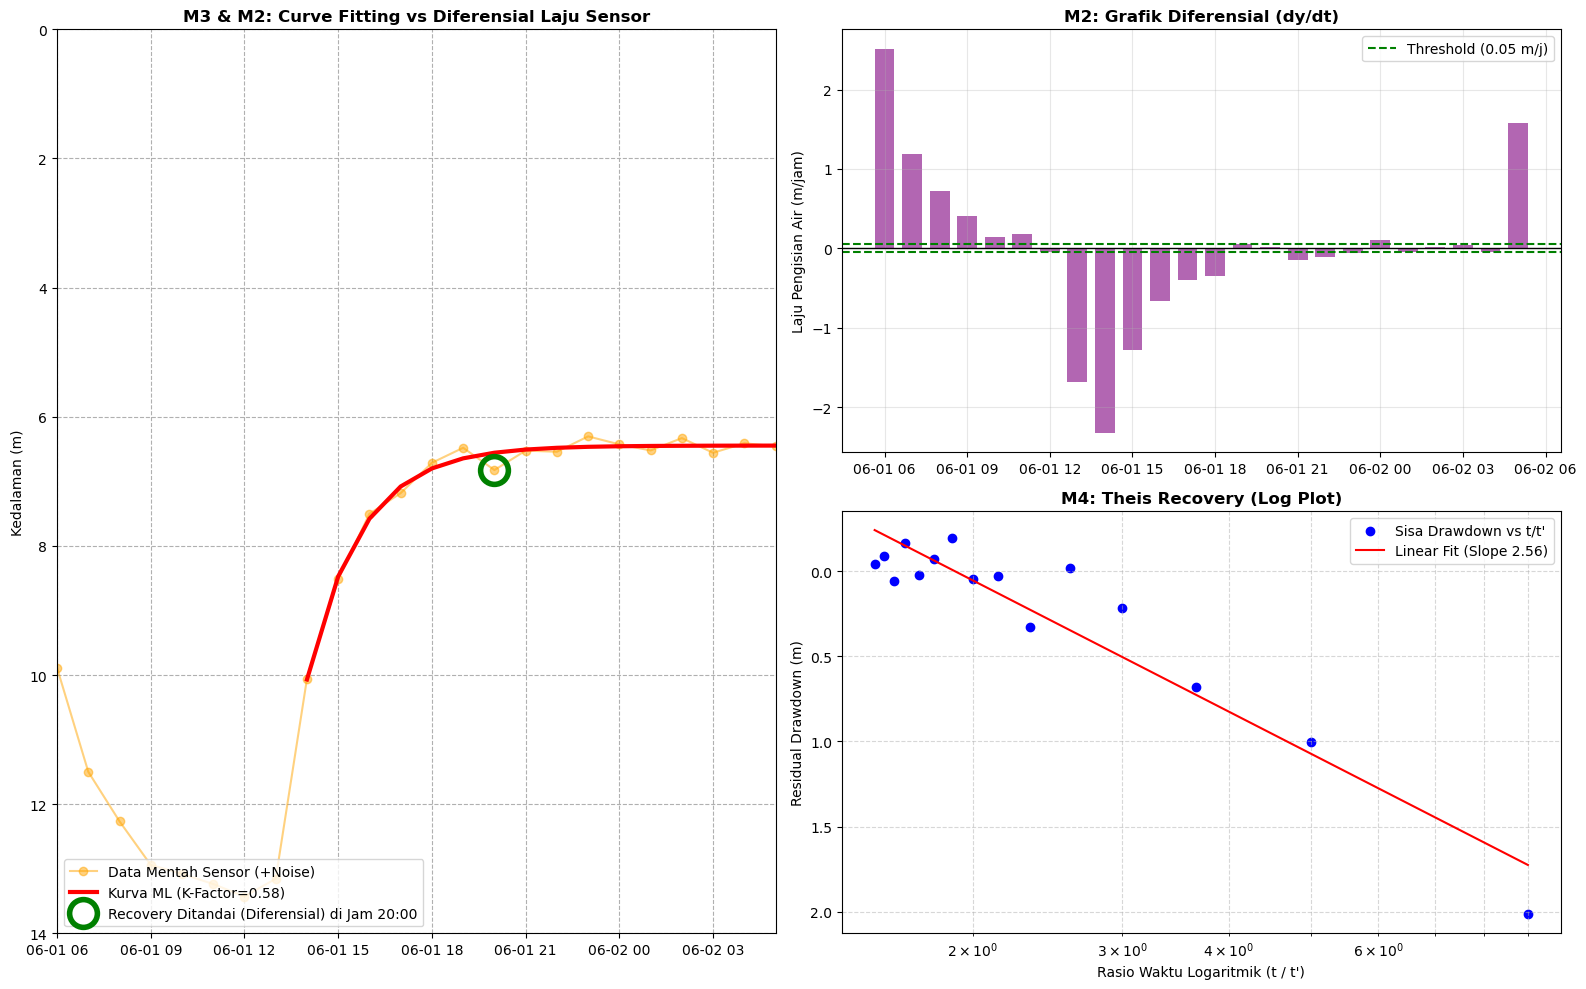

=========== KESIMPULAN HASIL PERHITUNGAN ===========
[M2] Waktu Eksekusi Pemulihan (Turunan <= 0.05 m): Jam 20:00
[M3] Konstanta Fit K-Factor ML (Recovery Rate Asli Bebas Noise): 0.58
[M4] Theis Slope M (Laju Penyusutan Regresi): 2.56 m/log-cycle


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =====================================================================
# METODE 2: METODE TURUNAN EKSPONENSIAL (DY/DT atau Laju Perubahan Laju)
# =====================================================================
# 2.A: Menghitung gradien per-jam dari seluruh populasi 6 Bulan awal tadi
df_tma['dy_dt'] = np.gradient(df_tma['tma_reading_meters'])

# 2.B: Threshold (Ambangan) - Air dianggap "Sudah Pulih" bila perubahannya 
# sangat kecil, misal kurang dari 5 cm per jam (0.05 meter) saat pompa mati.
THRESHOLD = 0.05 
# Boolean flag penanda kapan waktu recovery tercapai
df_tma['is_recovered'] = (df_tma['pump_status'] == 0) & (abs(df_tma['dy_dt']) <= THRESHOLD)


# Memotong Data Khusus 1 Hari (Siklus Jam pemompaan tgl 1 Juni s/d 2 Juni Pagi)
df_hari_1 = df_tma[(df_tma['timestamp'] >= '2025-06-01 06:00:00') & 
                   (df_tma['timestamp'] <= '2025-06-02 05:00:00')].copy()

# =====================================================================
# METODE 3: MACHINE LEARNING - SCIPY Curve Fitting 
# =====================================================================
# Mengambil eksklusif baris data SAAT POMPA BARU SAJA MATI s/d pagi besoknya.
# Jadwal pompa tadi: Mati jam 14:00 (jadi 14:00 dipakai sbg Index Start = 0)
mask_rec = (df_hari_1['timestamp'] >= '2025-06-01 14:00:00')
df_rec = df_hari_1[mask_rec].copy()

# Persamaan Matematis Hukum Fisika (Eksponensial Recovery)
def exp_recovery(t, statis, A, k):
    return statis + A * np.exp(-k * t)

# t array untuk Machine Learning (0 = jam awal mati, 1 = se-jam setelahnya, dst)
t_hours = np.arange(len(df_rec))
y_raw_data = df_rec['tma_reading_meters'].values

# Estimasi awalan / Initial Guess (Statis Baseline, Tinggi Max Kurva, Recovery Rate Guess)
base_guess = df_rec['static_baseline'].values[0]
p0_guess = [base_guess, max(y_raw_data) - base_guess, 0.3]

# [Proses Fit Terjadi Disini]
# Machine akan menebak konstanta "Statis tebakan", "A", & "k" (Recovery Factor) terbaik
popt, pcov = curve_fit(exp_recovery, t_hours, y_raw_data, p0=p0_guess)

statis_fit, A_fit, k_fit = popt
# Ini adalah garis MAHARDIKA mulus yang kebal terhadap Noise Sensor
y_smooth_fitted = exp_recovery(t_hours, statis_fit, A_fit, k_fit)


# =====================================================================
# METODE 4: THEIS RECOVERY METHOD (Klasik Hidrogeologi Logaritma)
# =====================================================================
df_theis = df_rec.copy()

# t_on (waktu sejak pompa Dinyalakan di 06:00) 
time_on_start = pd.to_datetime('2025-06-01 06:00:00')
# t_prime_off (waktu sejak pompa Dimatikan di 14:00)
time_off_start = pd.to_datetime('2025-06-01 14:00:00')

df_theis['t'] = (df_theis['timestamp'] - time_on_start).dt.total_seconds() / 3600.0
df_theis['t_prime'] = (df_theis['timestamp'] - time_off_start).dt.total_seconds() / 3600.0

# Hanya gunakan saat t_prime > 0 (menghindari error matematika logaritma/bagi 0)
df_theis = df_theis[df_theis['t_prime'] > 0]
df_theis['t_ratio'] = df_theis['t'] / df_theis['t_prime']
df_theis['residual_drawdown'] = df_theis['tma_reading_meters'] - base_guess

# Membuat Garis Tren Lurus linier dari Theis Method dengan Numpy polyfit (Regresi Linier)
# X = log10(t/t'), Y = Residual Drawdown
log_x = np.log10(df_theis['t_ratio'])
slope_m, sumbu_c = np.polyfit(log_x, df_theis['residual_drawdown'], 1)
lin_y = slope_m * log_x + sumbu_c


# =====================================================================
# PLOTTING DAN HASIL VISUALISASI METODE
# =====================================================================
fig = plt.figure(figsize=(16, 10))

# [PANEL 1 KIRI] METODE 2 DAN 3 
ax1 = plt.subplot(2, 2, (1, 3)) # Memakan tinggi
ax1.plot(df_hari_1['timestamp'], df_hari_1['tma_reading_meters'], 'o-', color='orange', label='Data Mentah Sensor (+Noise)', alpha=0.5)

# Plotting Garis Hasil Curve Fitting (Method 3)
ax1.plot(df_rec['timestamp'], y_smooth_fitted, '-', color='red', linewidth=3, label=f'Kurva ML (K-Factor={k_fit:.2f})')

# Plotting Mark/Tanda Kapan Waktu Recovered lewat Gradien (Method 2)
# Mencari titik Recovery pada hari Pertama
recovered_points = df_hari_1[df_hari_1['is_recovered'] == True]
if not recovered_points.empty:
    first_recover = recovered_points.iloc[0]
    ax1.plot(first_recover['timestamp'], first_recover['tma_reading_meters'], 'o', 
             markeredgecolor='green', markerfacecolor='none', markersize=20, markeredgewidth=4, 
             label=f"Recovery Ditandai (Diferensial) di Jam {first_recover['timestamp'].hour}:00")

ax1.set_ylim(14, 0) # Balik sumbu Y
ax1.set_xlim(df_hari_1['timestamp'].min(), df_hari_1['timestamp'].max())
ax1.set_title('M3 & M2: Curve Fitting vs Diferensial Laju Sensor', fontweight='bold')
ax1.set_ylabel('Kedalaman (m)')
ax1.grid(True, linestyle='--')
ax1.legend(loc='lower left')

# [PANEL KANAN ATAS] DY/DT (Visualisasi Method 2)
ax2 = plt.subplot(2, 2, 2)
ax2.bar(df_hari_1['timestamp'], df_hari_1['dy_dt'], color='purple', alpha=0.6, width=0.03)
ax2.axhline(0, color='black', linewidth=1)
ax2.axhline(THRESHOLD, color='green', linestyle='--')
ax2.axhline(-THRESHOLD, color='green', linestyle='--', label=f'Threshold ({THRESHOLD} m/j)')
ax2.set_title('M2: Grafik Diferensial (dy/dt)', fontweight='bold')
ax2.set_ylabel('Laju Pengisian Air (m/jam)')
ax2.grid(True, alpha=0.3)
ax2.legend()

# [PANEL KANAN BAWAH] THEIS RECOVERY PLOT (Method 4)
ax3 = plt.subplot(2, 2, 4)
ax3.scatter(df_theis['t_ratio'], df_theis['residual_drawdown'], color='blue', label='Sisa Drawdown vs t/t\'')
ax3.plot(df_theis['t_ratio'], lin_y, color='red', label=f'Linear Fit (Slope {slope_m:.2f})')

ax3.set_xscale('log') # Theis mutlak harus Logaritmik Sumbu X nya
ax3.invert_yaxis()    # Balik posisi 0 (tanpa sisa drawdown) di atas
ax3.set_title("M4: Theis Recovery (Log Plot)", fontweight='bold')
ax3.set_xlabel('Rasio Waktu Logaritmik (t / t\')')
ax3.set_ylabel('Residual Drawdown (m)')
ax3.grid(True, which="both", ls="--", alpha=0.5)
ax3.legend()

plt.tight_layout()
plt.show()

# Menampilkan angka hasil
print("=========== KESIMPULAN HASIL PERHITUNGAN ===========")
print(f"[M2] Waktu Eksekusi Pemulihan (Turunan <= {THRESHOLD} m): Jam {first_recover['timestamp'].hour}:00")
print(f"[M3] Konstanta Fit K-Factor ML (Recovery Rate Asli Bebas Noise): {k_fit:.2f}")
print(f"[M4] Theis Slope M (Laju Penyusutan Regresi): {slope_m:.2f} m/log-cycle")
print("====================================================")


In [7]:
import math

# =====================================================================
# KALKULASI DURASI PEMULIHAN (DALAM MENIT)
# =====================================================================
time_off_start = pd.to_datetime('2025-06-01 14:00:00')

# M2: Durasi Aktual dari Diferensial (Data Real)
if not recovered_points.empty:
    waktu_pulih_m2 = first_recover['timestamp']
    # Selisih = Waktu deteksi - Waktu pompa dimatikan
    durasi_m2_detik = (waktu_pulih_m2 - time_off_start).total_seconds()
    durasi_m2_menit = durasi_m2_detik / 60.0
else:
    durasi_m2_menit = 0

# M3: Prediksi Waktu dari Rumus Machine Learning 
# Kita cari tau di menit ke-berapa kurva M3 nyaris menyentuh garis Statis (misal bersisa 5 cm / 0.05m lagi)
# Rumusnya: A * exp(-k * t) = 0.05
# t = -ln(0.05 / A) / k   --> (keluaran 't' masih dalam spesifikasi Jam)
sisa_target_m = 0.05 # sisa 5 sentimeter air
if A_fit > sisa_target_m:
    waktu_prediksi_jam = -math.log(sisa_target_m / A_fit) / k_fit
    durasi_m3_menit = waktu_prediksi_jam * 60.0 # Konversi ke menit
else:
    durasi_m3_menit = 0

print("=========== KESIMPULAN HASIL PERHITUNGAN RECOVERY ===========")
print(f"Mesin Pompa Dimatikan pada        : {time_off_start.strftime('%H:%M WIB')}")
print("-" * 61)
print(f"[M2] Waktu Eksekusi Pemulihan (Tol. {THRESHOLD} m/jam)  : {waktu_pulih_m2.strftime('%H:%M WIB')}")
print(f"[M2] Total Durasi Pemulihan Akuifer (Aktual): {durasi_m2_menit:.0f} Menit")
print("-" * 61)
print(f"[M3] Konstanta Fit K-Factor ML (Bebas Noise): {k_fit:.4f}")
print(f"[M3] Prediksi Absolut Waktu Pulih (Matematik): {durasi_m3_menit:.0f} Menit")
print("-" * 61)
print(f"[M4] Theis Slope M (Laju Penyusutan Regresi): {slope_m:.2f} m/log-cycle")
print("=============================================================")

=========== KESIMPULAN HASIL PERHITUNGAN RECOVERY ===========
Mesin Pompa Dimatikan pada        : 14:00 WIB
-------------------------------------------------------------
[M2] Waktu Eksekusi Pemulihan (Tol. 0.05 m/jam)  : 20:00 WIB
[M2] Total Durasi Pemulihan Akuifer (Aktual): 360 Menit
-------------------------------------------------------------
[M3] Konstanta Fit K-Factor ML (Bebas Noise): 0.5813
[M3] Prediksi Absolut Waktu Pulih (Matematik): 442 Menit
-------------------------------------------------------------
[M4] Theis Slope M (Laju Penyusutan Regresi): 2.56 m/log-cycle
